# Chess RL — Resumable Self-Play Training

Runs the **self-play → train** loop one iteration at a time. Every *completed* iteration
saves a checkpoint and logs its metrics, so you can interrupt the kernel at any moment and
resume later with no corruption.

**Usage**
1. Launch Jupyter from your repo root (`~/semester_6/chess_bot`) so imports and the
   move-lookup path resolve.
2. Run sections **1–4** once per session (setup).
3. Run **section 5** whenever the laptop is idle. Press the interrupt button (■) to stop —
   the last completed iteration is always safe. Re-run section 5 (or sections 4+5 after a
   kernel restart) to resume from the latest checkpoint.
4. Use **section 6** to inspect progress.

## 1. Configuration

In [ ]:
import os

# ===== EDIT THESE =====
REPO_ROOT = os.path.abspath(".")   # assumes Jupyter was launched from the repo root

# Network — MUST match the checkpoints you load
NUM_RES_BLOCKS = 10
NUM_FILTERS    = 256

# Self-play
GAMES_PER_ITER  = 10     # higher (e.g. 10) for anything but testing
NUM_SIMULATIONS = 100    # lower (e.g. 30-50) for faster but noisier iterations
MAX_MOVES       = 100   # Could be set to 150 later, moves are counted falsly
TEMP_THRESHOLD  = 30

# Training
TRAIN_EPOCHS     = 1
TRAIN_BATCH_SIZE = 32

# Parallel self-play across CPU cores.
# Serial (False) is the safe default and uses the in-memory network directly.
# If you set this True, see the note in section 3 about the worker import path.
USE_PARALLEL = False
NUM_WORKERS  = 4

# Persistence
SAVE_DATA = True   # also pickle the raw positions for each iteration

# ===== Derived paths =====
RUN_DIR  = os.path.join(REPO_ROOT, "reinforcement_learning", "training_runs")
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
DATA_DIR = os.path.join(RUN_DIR, "data")
GAMES_DIR = os.path.join(RUN_DIR, "games")
LOG_DIR  = os.path.join(RUN_DIR, "logs")
LOG_FILE = os.path.join(LOG_DIR, "training.log")
ITER_CSV = os.path.join(LOG_DIR, "iterations.csv")
LOOKUP_PATH = os.path.join(REPO_ROOT, "reinforcement_learning", "move_lookup.json")

for d in (CKPT_DIR, DATA_DIR, LOG_DIR, GAMES_DIR):
    os.makedirs(d, exist_ok=True)

print("Checkpoints:", CKPT_DIR)
print("Logs:       ", LOG_DIR)

Checkpoints: /home/timle/semester_6/chess_bot/reinforcement_learning/training_runs/checkpoints
Logs:        /home/timle/semester_6/chess_bot/reinforcement_learning/training_runs/logs


## 2. Imports & logging

In [2]:
import sys
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import time
import glob
import csv
import pickle
import json
import logging
from datetime import datetime

import numpy as np

from reinforcement_learning.monte_carlo_tree_search.mcts_v2 import MCTS, SelfPlayGame
from reinforcement_learning.helpers.converter import Converter
from reinforcement_learning.networks.big_network import BigNetwork

# force=True resets handlers so re-running this cell doesn't duplicate log lines
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.FileHandler(LOG_FILE), logging.StreamHandler()],
    force=True,
)
log = logging.getLogger("train")


def log_iteration_csv(metrics: dict):
    """Append one iteration's metrics as a row in iterations.csv."""
    write_header = not os.path.exists(ITER_CSV)
    with open(ITER_CSV, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(metrics.keys()))
        if write_header:
            w.writeheader()
        w.writerow(metrics)

I0000 00:00:1781506191.832575    3365 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781506191.838595    3365 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781506194.702427    3365 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781506194.704386    3365 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 3. Helper functions

`run_one_iteration` does self-play → train → save → return metrics. The checkpoint is
written only at the very end, which is what makes interrupting safe.

**Note on parallel self-play:** if you set `USE_PARALLEL = True`, the worker in
`mcts_v2.py` (`_selfplay_worker`) must import your network with the full package path —
`from reinforcement_learning.networks.big_network import BigNetwork` — and its
`SelfPlayGame(...)` call should pass `resign_threshold=None` (or your `SelfPlayGame`
default must already be `None`). The serial path below handles resign explicitly.

In [3]:
def latest_iteration():
    """Highest completed iteration number on disk, or None if there are no checkpoints."""
    ckpts = glob.glob(os.path.join(CKPT_DIR, "iter_*.weights.h5"))
    if not ckpts:
        return None
    nums = []
    for c in ckpts:
        name = os.path.basename(c)
        nums.append(int(name[len("iter_"):-len(".weights.h5")]))
    return max(nums)


def flatten_games(games):
    """list[list[sample]] (per game) -> flat list[sample] (per position)."""
    return [s for game in games for s in game]


def generate_games(network, mcts, prev_weight_path):
    """Return a flat list of position samples from GAMES_PER_ITER self-play games."""
    records = []
    if USE_PARALLEL:
        from reinforcement_learning.monte_carlo_tree_search.mcts_v2 import play_games_parallel
        games = play_games_parallel(
            n_games=GAMES_PER_ITER, weight_path=prev_weight_path, lookup_path=LOOKUP_PATH,
            num_simulations=NUM_SIMULATIONS, num_res_blocks=NUM_RES_BLOCKS,
            num_filters=NUM_FILTERS, num_workers=NUM_WORKERS,
            max_moves=MAX_MOVES, temperature_threshold=TEMP_THRESHOLD,
        )
        # NOTE: the parallel worker doesn't return records yet
    else:
        games = []
        for g in range(GAMES_PER_ITER):
            game = SelfPlayGame(
                mcts, temperature_threshold=TEMP_THRESHOLD,
                max_moves=MAX_MOVES, resign_threshold=None,
            )
            games.append(game.play())
            records.append(game.record)
            log.info(f"  game {g + 1}/{GAMES_PER_ITER} done")
    return flatten_games(games), records

def save_games_json(iteration, records, prev_weight_path, num_positions, selfplay_seconds):
    payload = {
        "iteration": iteration,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "generated_with_weights": os.path.basename(prev_weight_path),  # the net that played
        "config": {
            "games_per_iter": GAMES_PER_ITER,
            "num_simulations": NUM_SIMULATIONS,
            "max_moves": MAX_MOVES,
            "temperature_threshold": TEMP_THRESHOLD,
            "num_res_blocks": NUM_RES_BLOCKS,
            "num_filters": NUM_FILTERS,
        },
        "num_games": len(records),
        "num_positions": num_positions,
        "selfplay_seconds": round(selfplay_seconds, 1),
        "games": [{"game": i, **rec} for i, rec in enumerate(records)],
    }
    with open(os.path.join(GAMES_DIR, f"iter_{iteration}.json"), "w") as f:
        json.dump(payload, f, indent=2)

def run_one_iteration(iteration, network, mcts, converter, prev_weight_path):
    # 1. SELF-PLAY
    t0 = time.perf_counter()
    samples, records = generate_games(network, mcts, prev_weight_path)
    t_selfplay = time.perf_counter() - t0
    if not samples:
        raise RuntimeError("Self-play produced no positions — check max_moves / resign.")
    
    save_games_json(iteration, records, prev_weight_path, len(samples), t_selfplay)

    if SAVE_DATA:
        with open(os.path.join(DATA_DIR, f"iter_{iteration}.pkl"), "wb") as f:
            pickle.dump(samples, f)

    # 2. TRAIN
    t1 = time.perf_counter()
    board_tensors  = np.array([s["board_tensor"]  for s in samples])
    policy_targets = np.array([s["policy_target"] for s in samples])
    value_targets  = np.array([[s["value_target"]] for s in samples], dtype=np.float32)
    history = network.train(
        board_tensors, policy_targets, value_targets,
        epochs=TRAIN_EPOCHS, batch_size=TRAIN_BATCH_SIZE, verbose=0,
    )
    t_train = time.perf_counter() - t1

    # 3. CHECKPOINT (written last -> interrupting before here loses nothing saved)
    weight_path = os.path.join(CKPT_DIR, f"iter_{iteration}.weights.h5")
    network.save(weight_path)

    h = history.history
    def last(key):
        v = h.get(key)
        return round(float(v[-1]), 4) if v else None

    return {
        "iteration": iteration,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "num_games": GAMES_PER_ITER,
        "num_positions": len(samples),
        "selfplay_seconds": round(t_selfplay, 1),
        "train_seconds": round(t_train, 1),
        "total_seconds": round(t_selfplay + t_train, 1),
        "loss": last("loss"),
        "policy_loss": last("policy_output_loss"),
        "value_loss": last("value_output_loss"),
        "weights_file": os.path.basename(weight_path),
    }


def run_iterations(num_iterations, network, mcts, converter):
    """Run up to num_iterations, resuming from the latest checkpoint.
    Interrupt the kernel any time; the last completed iteration is always saved."""
    start = latest_iteration()
    if start is None:
        raise RuntimeError("No checkpoint. Run section 4 first to create iter_0.")

    session_t0 = time.perf_counter()
    completed = 0
    log.info(f"=== Session start: resuming after iter_{start}, planning {num_iterations} iters ===")
    try:
        for it in range(start + 1, start + 1 + num_iterations):
            log.info(f"--- Iteration {it} starting ---")
            prev_path = os.path.join(CKPT_DIR, f"iter_{it - 1}.weights.h5")
            m = run_one_iteration(it, network, mcts, converter, prev_path)
            log_iteration_csv(m)
            log.info(
                f"Iteration {it} DONE in {m['total_seconds']}s "
                f"(self-play {m['selfplay_seconds']}s, train {m['train_seconds']}s) | "
                f"loss={m['loss']} | {m['num_positions']} positions | saved {m['weights_file']}"
            )
            completed += 1
    except KeyboardInterrupt:
        log.warning(
            f"Interrupted. {completed} iteration(s) this session. "
            f"Last safe checkpoint: iter_{latest_iteration()}."
        )
        print("\n⏹  Stopped cleanly — safe to use your laptop. Re-run to resume.")
    finally:
        mins = (time.perf_counter() - session_t0) / 60
        log.info(f"=== Session end: {completed} iterations, {mins:.1f} min ===")

In [ ]:
# THIS GETS USED TO ARCHIVE THE ENTIRE DIRECTORY TO GET TO A NEW STARTING POINT

# import shutil
# from datetime import datetime

# if os.path.isdir(RUN_DIR):
#     dst = RUN_DIR + "_archived_" + datetime.now().strftime("%Y%m%d_%H%M%S")
#     shutil.move(RUN_DIR, dst)
#     print("Archived old run to:", dst)

# for d in (CKPT_DIR, DATA_DIR, GAMES_DIR, LOG_DIR):
#     os.makedirs(d, exist_ok=True)
# print("Fresh, empty run dirs created.")

Archived old run to: /home/timle/semester_6/chess_bot/reinforcement_learning/training_runs_archived_20260614_230739
Fresh, empty run dirs created.


## 4. Build / resume the network (run once per session)

In [4]:
def setup_network():
    network = BigNetwork(num_res_blocks=NUM_RES_BLOCKS, num_filters=NUM_FILTERS)
    converter = Converter(lookup_path=LOOKUP_PATH)
    mcts = MCTS(network=network, converter=converter, num_simulations=NUM_SIMULATIONS)

    n = latest_iteration()
    if n is None:
        path = os.path.join(CKPT_DIR, "iter_0.weights.h5")
        network.save(path)
        log.info("No checkpoint found — saved random init as iter_0.")
    else:
        path = os.path.join(CKPT_DIR, f"iter_{n}.weights.h5")
        network.load(path)
        log.info(f"Resumed from {os.path.basename(path)}.")
    return network, converter, mcts


network, converter, mcts = setup_network()

08:50:23 | INFO | No checkpoint found — saved random init as iter_0.


## 5. Run training iterations

Run this whenever the laptop is free. Set the number high — it will stop when you interrupt
the kernel, and every completed iteration is checkpointed and logged.

In [5]:
run_iterations(10, network, mcts, converter)

08:50:34 | INFO | === Session start: resuming after iter_0, planning 10 iters ===
08:50:34 | INFO | --- Iteration 1 starting ---


  Move 20: rnbqkbnr/p1pppp2/7p/6pP/p2P3R/2P2N2/1P1QPPP1/RNB1KB2 w Qkq g6 0 11
  Move 40: rn1q2nr/2pppk2/7p/p4ppP/P1PbP1bR/1Q3P2/1B1N4/RN2KB2 w Q - 0 21
  Move 60: Q1q3nr/3pp1k1/n1p4p/p1P1P1pP/P4pb1/5P2/1B1N4/RN2KB1R w - - 3 31
  Move 80: 6n1/q3p1k1/2p4p/p1PpP1pP/P4pb1/R2B1P1R/1B1N2K1/1N6 w - - 0 41


09:05:51 | INFO |   game 1/10 done


  Move 100: 6n1/4p2k/2p4p/p3P1pP/q2p1pb1/NN5R/8/B1R3K1 w - - 0 51
  Game over after 100 moves: 1/2-1/2
  Move 20: rn1q1kn1/p1pb4/3p1ppr/1p2p3/7P/P2P1P2/P1P1P3/RNBQKBNR w KQ - 0 11
  Move 40: rnq2kn1/B7/2pp1pp1/1pr5/p1N1p2P/P1PP1PK1/P3P3/R3QBNR w - - 1 21
  Move 60: r6q/B3k3/1npp1ppn/6rP/ppN5/P1PPKP1N/P3P2Q/R4B1R w - - 3 31
  Move 80: rq6/B4n1P/2pp1kp1/4N3/ppnK4/P1PPPP2/P7/3R1BrR w - - 3 41


09:23:29 | INFO |   game 2/10 done


...

20:01:27 | INFO |   game 9/10 done


  Move 100: 1r1k2n1/p6r/1pp2b2/nPqb2PP/P2Pp1R1/2B1p3/RKPN1P1N/5B2 w - - 20 51
  Game over after 100 moves: 1/2-1/2
  Move 20: 1rb1kb1r/p2qnp2/n1p3p1/1p1pp2p/1P1P3P/4PP2/P1P1QKP1/RNB2BNR w k - 3 11
  Move 40: brk1qb1r/p3n3/n1P3p1/3ppp1p/1P1P3P/2PQPPKN/6P1/RN2BBR1 w - - 1 21
  Move 60: brk3r1/p3n3/nqP2b2/3p1p1p/1P1Pp1pP/2PQPP1N/6PK/RN2BB1R w - - 2 31
  Move 80: brk5/p3n2r/nqP2b2/3p1p1p/1P1Pp2P/2PQPP1p/6PK/RN2BB1R w - - 6 41


20:16:05 | INFO |   game 10/10 done


  Move 100: b1k5/pr2n1r1/1qP5/2npbp1p/1P1Pp2P/2PQPP1p/5BPK/RN3BR1 w - - 26 51
  Game over after 100 moves: 1/2-1/2


20:16:19 | INFO | Iteration 10 DONE in 9634.9s (self-play 9622.3s, train 12.7s) | loss=4.2441 | 1000 positions | saved iter_10.weights.h5
20:16:19 | INFO | === Session end: 10 iterations, 1439.0 min ===


## 6. Inspect progress

,iteration,timestamp,num_games,num_positions,selfplay_seconds,train_seconds,total_seconds,loss,policy_loss,value_loss,weights_file
0,1,2026-06-15T10:59:45,10,834,7318.5,23.4,7341.9,17.4206,16.6901,0.5650,iter_1.weights.h5
1,2,2026-06-15T13:35:03,10,853,8443.0,15.3,8458.3,7.7760,7.1197,0.6386,iter_2.weights.h5
2,3,2026-06-15T16:39:00,10,989,8672.7,10.9,8683.6,5.7902,5.5938,0.1949,iter_3.weights.h5
3,4,2026-06-15T18:49:35,10,915,7537.4,9.9,7547.3,5.5753,5.2623,0.3013,iter_4.weights.h5
4,5,2026-06-15T21:04:08,10,925,7774.1,10.6,7784.7,5.3281,5.1074,0.2191,iter_5.weights.h5
5,6,2026-06-16T10:09:40,10,740,9693.8,16.4,9710.2,5.9874,5.0728,0.9379,iter_6.weights.h5
6,7,2026-06-16T12:54:17,10,926,9865.2,11.1,9876.4,5.3440,4.7616,0.5811,iter_7.weights.h5
7,8,2026-06-16T15:12:38,10,964,8353.2,11.0,8364.2,4.7558,4.6804,0.0693,iter_8.weights.h5
8,9,2026-06-16T17:39:35,10,876,8903.4,11.9,8915.3,4.7356,4.4552,0.2748,iter_9.weights.h5
9,10,2026-06-16T20:16:19,10,1000,9622.3,12.7,9634.9,4.2441,4.2417,0.0302,iter_10.weights.h5


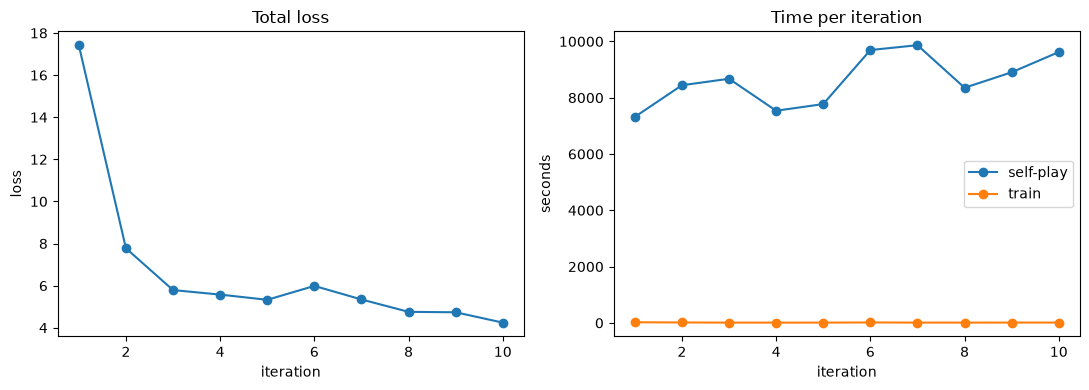

In [6]:
try:
    import pandas as pd
    df = pd.read_csv(ITER_CSV)
    display(df.tail(20))
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        ax[0].plot(df["iteration"], df["loss"], marker="o")
        ax[0].set(title="Total loss", xlabel="iteration", ylabel="loss")
        ax[1].plot(df["iteration"], df["selfplay_seconds"], marker="o", label="self-play")
        ax[1].plot(df["iteration"], df["train_seconds"], marker="o", label="train")
        ax[1].set(title="Time per iteration", xlabel="iteration", ylabel="seconds")
        ax[1].legend()
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("Plotting skipped:", e)
except FileNotFoundError:
    print("No iterations logged yet — run section 5 first.")